# Organization Score (Distance-Rank)

> Condense semantic organization into a single scalar per subject.

The organization score measures semantic organization by computing, for each transition, the percentile rank of the actual semantic distance among all available semantic distances. A score of 0.5 indicates chance; scores above 0.5 reflect transitions to semantically closer items.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import warnings
from jaxcmr.analyses.distrank import plot_distrank, subject_distrank
from jaxcmr.analyses.distrank import test_distrank as run_test_distrank
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/Dupertuys2026.h5"
distance_matrix_path = "data/Dupertuys2026_semantic_distances.npy"
figure_dir = "results/figures"
figure_str = ""
ylim = None
yticks = None
trial_queries = [
    "data['list_type'] == 1",
    "data['list_type'] == 2",
    "data['list_type'] == 3",
]
labels = ["Mixed", "Pure emotional", "Pure neutral"]
color_cycle = ["#2ca02c", "#ff4d4d", "#4da3df"]
contrast_name = None
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
distance_matrix_path = os.path.join(project_root, distance_matrix_path)
data = load_data(data_path)
distance_matrix = np.load(distance_matrix_path).astype(np.float32)
trial_masks = [generate_trial_mask(data, trial_query) for trial_query in trial_queries]
datasets = [data] * len(trial_masks)

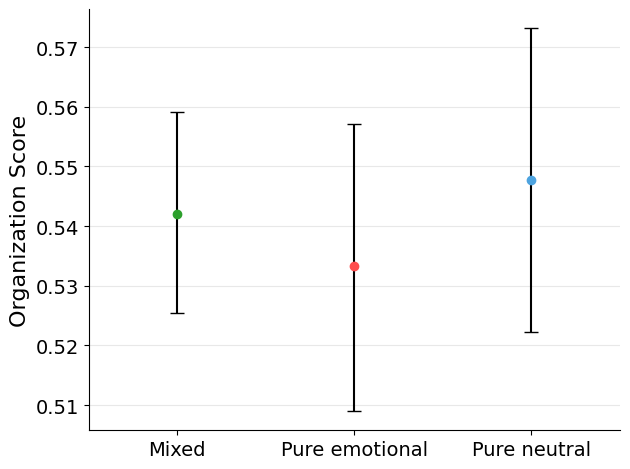

In [4]:
plot_distrank(
    datasets=datasets,
    trial_masks=trial_masks,
    distance_matrix=distance_matrix,
    labels=labels,
    color_cycle=color_cycle,
    contrast_name=contrast_name,
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
if yticks is not None:
    for ax in plt.gcf().axes:
        ax.set_yticks(yticks)
save_figure(figure_dir, figure_str)

In [5]:
for i in range(len(trial_masks)):
    factors = subject_distrank(data, trial_masks[i], distance_matrix)
    result = run_test_distrank(factors)

    print(f"\n{'='*70}")
    print(f"Organization Score: {labels[i]}")
    print(f"{'='*70}")
    print(result)


Organization Score: Mixed
N=122
Mean factor: 0.5420
t-stat: 4.925 p=0.0000
W-stat: 1953.0 p=0.0000



Organization Score: Pure emotional
N=122
Mean factor: 0.5333
t-stat: 2.707 p=0.0078
W-stat: 2762.0 p=0.0115



Organization Score: Pure neutral
N=122
Mean factor: 0.5477
t-stat: 3.626 p=0.0004
W-stat: 2347.0 p=0.0005


## Interpretation

The plot shows one per-subject mean distance factor for each list type.

- **Scores above 0.5**: semantic clustering — transitions favor semantically closer available images.
- **Scores near 0.5**: chance-level semantic organization.
- **List-type separation**: differences among mixed, pure emotional, and pure neutral lists indicate that semantic organization differs by stimulus-list context.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `distance_matrix_path` — path to a numpy file containing a pairwise distance matrix indexed by item ID.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits for the point plot, or `None` for automatic scaling.
- `yticks` — y-axis ticks for the point plot, or `None` for automatic ticks.
- `trial_queries` — Python expressions evaluated against the dataset to select trials.
- `labels` — x-axis labels matching `trial_queries`.
- `color_cycle` — point colors matching `labels`.
- `contrast_name` — label describing the plotted contrast.
- `confidence_level` — confidence level for subject-wise error bars.

The standard Distance-CRP template shows the full distance-binned curve; this template collapses the same semantic-distance organization into a scalar factor score.